<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day33_Stacking%26Voting_ensembles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Base models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Ensemble methods
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
!pip install xgboost lightgbm -q
import xgboost as xgb
import lightgbm as lgb

##Ensemble Types Overview

| Type | How It Works | Example |
|------|--------------|--------|
| **Bagging** | Same algorithm, different data samples | Random Forest |
| **Boosting** | Sequential, fix previous errors | XGBoost, LightGBM |
| **Voting** | Different algorithms, vote on prediction | VotingClassifier |
| **Stacking** | Different algorithms, meta-learner combines | StackingClassifier |

In [6]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native_country', 'income'
]

df = pd.read_csv(url, names=columns, sep=',\s*',  engine='python', na_values='?')
df = df.dropna()

print(f"Dataset: {df.shape[0]:,} samples")

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3469/1693946866.py:9: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, names=columns, sep=',\s*',  engine='python', na_values='?')


Dataset: 30,162 samples


In [8]:
x = df.drop('income', axis=1)
y = (df['income'] =='>50K').astype(int)

numeric_cols = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = x.select_dtypes(include=['object']).columns.tolist()

#Preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

x_processed = preprocessor.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(x_train):,}, Test: {len(x_test):,}")
print(f"Features: {x_processed.shape[1]}")

Train: 24,129, Test: 6,033
Features: 104


Individual Model Baselines

In [11]:
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1),
    'Gradient Booosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, max_depth=5, verbosity=0, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=5, random_state=42, verbose=-1, n_jobs=-1),
    'SVM':  SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

individual_results = []
trained_models = {}

for name, model in base_models.items():
  start = time.time()
  model.fit(x_train, y_train)
  train_time = time.time() - start

  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  individual_results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'Time': train_time})
  trained_models[name] = model

  print(f"{name:<25} Acc:  {acc:.4f} F1: {f1:.4f}")

resullts_df = pd.DataFrame(individual_results).sort_values('F1', ascending=False)

Logistic Regression       Acc:  0.8470 F1: 0.6625
Random Forest             Acc:  0.8563 F1: 0.6677
Gradient Booosting        Acc:  0.8628 F1: 0.6983
XGBoost                   Acc:  0.8671 F1: 0.7107


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM                  Acc:  0.8646 F1: 0.7013
SVM                       Acc:  0.8502 F1: 0.6639
KNN                       Acc:  0.8268 F1: 0.6365


Hard Voting

In [13]:
# Hard voting: Majority vote on predicted class
# Each model gets 1 vote, class with most votes wins

voting_hard = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)),
        ('xgb', xgb.XGBClassifier(n_estimators=100, random_state=42, max_depth=5, verbosity=0, n_jobs=-1)),
        ('lgb', lgb.LGBMClassifier(n_estimators=100, max_depth=5, random_state=42, verbose=-1, njobs=-1))
    ],
    voting='hard'
)

print("Training Hard Voting Calssifier . . . ")
start = time.time()
voting_hard.fit(x_train, y_train)
hard_time = time.time() - start

y_pred_hard = voting_hard.predict(x_test)
hard_acc = accuracy_score(y_test, y_pred_hard)
hard_f1 = f1_score(y_test, y_pred_hard)

print(f"Results of hard voting:")
print(f" Accuracy: {hard_acc:.4f}")
print(f" F1 Score: {hard_f1:.4f}")
print(f" Time: {hard_time:.4f}")

Training Hard Voting Calssifier . . . 
Results of hard voting:
 Accuracy: 0.8647
 F1 Score: 0.7002
 Time: 41.6490


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Soft Voting

In [15]:
#Soft voting: Average predicted probabilties
# More confident predictions have more influence

voting_soft = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42, verbose=-1, n_jobs=-1)),
        ('lgb', lgb.LGBMClassifier(n_estimators=100, max_depth=5, random_state=42, verbose=-1, n_jobs=-1))
    ],
    voting='soft'
)

print("Training soft voting classifier . . .")
start = time.time()
voting_soft.fit(x_train, y_train)
soft_time = time.time() - start

y_pred_soft = voting_soft.predict(x_test)
soft_acc = accuracy_score(y_test, y_pred_soft)
soft_f1 = f1_score(y_test, y_pred_soft)

print("Results of soft voting:")
print(f" Accuracy: {soft_acc:.4f}")
print(f" F1 Score: {soft_f1:.4f}")
print(f"Time: {soft_time:.4f}")

Training soft voting classifier . . .


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:11:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Results of soft voting:
 Accuracy: 0.8659
 F1 Score: 0.7007
Time: 29.3654


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
# Hard vs Soft Comparison
print("Hard vs soft voting:")
print(f" Accuracy: {soft_acc - hard_acc:.4f}")
print(f" F1 Score: {soft_f1 - hard_f1:.4f}")
print(f" Time: {soft_time - hard_time:.4f}")

#Soft voting usually wins because it uses probability confidence

Hard vs soft voting:
 Accuracy: 0.0012
 F1 Score: 0.0005
 Time: -12.2836


Weighted Voting

In [19]:
# Weighted Voting: Give better models more weight
# Weights based on individual F1 scores

weights = [
    resullts_df[resullts_df['Model'] == 'Logistic Regression']['F1'].values[0],
    resullts_df[resullts_df['Model'] == 'Random Forest']['F1'].values[0],
    resullts_df[resullts_df['Model'] == 'Gradient Booosting']['F1'].values[0],
    resullts_df[resullts_df['Model'] == 'XGBoost']['F1'].values[0],
    resullts_df[resullts_df['Model'] == 'LightGBM']['F1'].values[0]
]

print(f"Model weights baseed on f1: {(f'{w:.3f}' for w in weights)}")

voting_weighted = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42, verbosity=0, n_jobs=-1)),
        ('lgb', lgb.LGBMClassifier(n_estimators=100, max_depth=5, random_state=42, verbose=-1,  n_jobs=-1))
    ],
    voting='soft',
    weights=weights
)

print(f"Training weighted voting classifier: ")
voting_weighted.fit(x_train, y_train)

y_pred_weighted = voting_weighted.predict(x_test)
weighted_acc = accuracy_score(y_test, y_pred_weighted)
weighted_f1 = f1_score(y_test, y_pred_weighted)

print(f"results: ")
print(f" Accuracy: {weighted_acc:.4f}")
print(f" F1 Score: {weighted_f1:.4f}")

Model weights baseed on f1: <generator object <genexpr> at 0x7b91ce472e90>
Training weighted voting classifier: 
results: 
 Accuracy: 0.8657
 F1 Score: 0.6964


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stacking Classifier

In [21]:
# Stacking: Train a meta-learner on base model predictions
# level 0: Base models make predictions
# level 1: Meta-learner learns to combine these

stacking = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42, verbosity=0, n_jobs=-1)),
        ('lgb', lgb.LGBMClassifier(n_estimators=100, max_depth=5, verbose=-1, n_jobs=-1))
    ],
    final_estimator = LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

print(f"Training stacking classifier: ")
start = time.time()
stacking.fit(x_train, y_train)
stack_time = time.time() - start
y_pred_stack = stacking.predict(x_test)
stack_acc = accuracy_score(y_test, y_pred_stack)
stack_f1 = f1_score(y_test, y_pred_stack)

print(f"Results: ")
print(f" Accuracy: {stack_acc:.4f}")
print(f" F1 Score: {stack_f1:.4f}")
print(f" Time: {stack_time:.4f}")

Training stacking classifier: 
Results: 
 Accuracy: 0.8656
 F1 Score: 0.7065
 Time: 170.7628


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [24]:
#Stacking with different meta-learner
stacking_rf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42, verbosity=0, n_jobs=-1)),
        ('lgb', lgb.LGBMClassifier(n_estimators=100, max_depth=5, n_jobs=-1, random_state=42, verbose=-1)),
    ],
    final_estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    cv=5,
    n_jobs=-1
)

print(f"Training stacking classifier: ")
stacking_rf.fit(x_train, y_train)

y_pred_stack_rf = stacking_rf.predict(x_test)
stack_rf_f1 = f1_score(y_test, y_pred_stack_rf)

print(f"Stacking (RF meta): F1: {stack_rf_f1:.4f}")

Training stacking classifier: 
Stacking (RF meta): F1: 0.6882


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stacking with Passthrough

In [26]:
#Passthrough: include original features + base model predictions
stacking_passthrough = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(n_estimators=100,max_depth=5, random_state=42, verbosity=0, n_jobs=-1))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    passthrough=True,
    cv=5,
    n_jobs=-1
)

print(f"Training stacking classifier: ")
stacking_passthrough.fit(x_train, y_train)

y_pred_pass = stacking_passthrough.predict(x_test)
pass_f1 = f1_score(y_test, y_pred_pass)

print(f"Stacking (passthrough): F1: {pass_f1:.4f}")

Training stacking classifier: 


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Stacking (passthrough): F1: 0.7141


Model Diversity Analysis

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


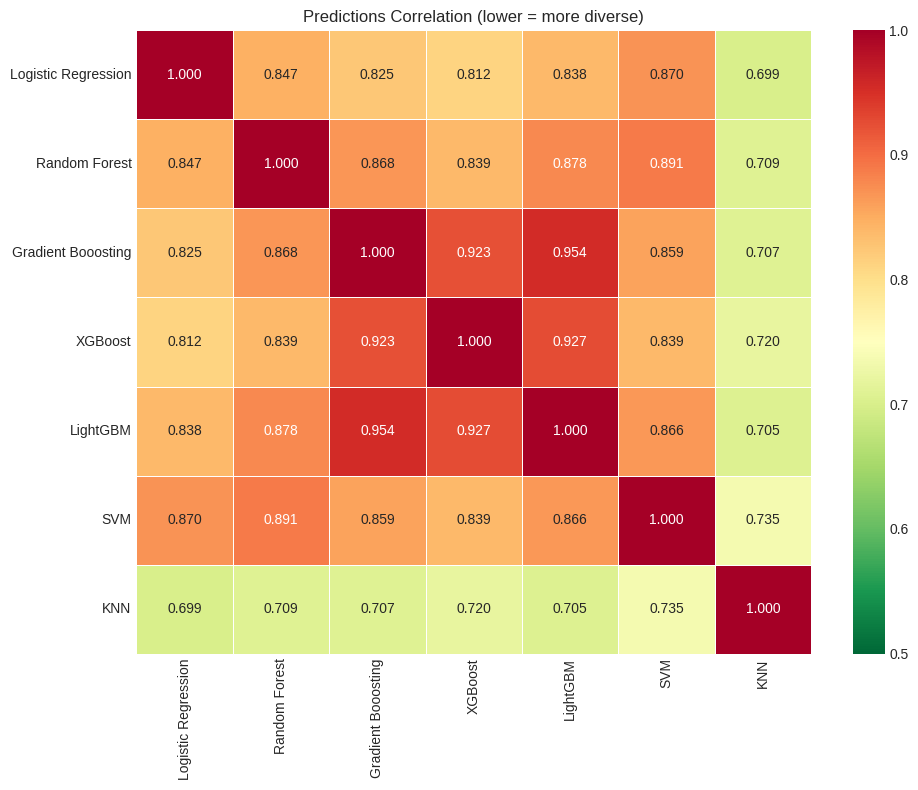

In [27]:
#Check predictions correlation
# more cancellations = high diversity = good for ensembles

predictions = {}

for name, model in trained_models.items():
  predictions[name] = model.predict(x_test)

pred_df = pd.DataFrame(predictions)
correlation = pred_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0.5, vmax=1.0, linewidths=0.5)
plt.title('Predictions Correlation (lower = more diverse)')
plt.tight_layout()
plt.show()


In [29]:
# All results
all_results = individual_results.copy()

ensemble_results = [
    {'Model': 'Hard Voting', 'Accuracy': hard_acc, 'F1': hard_f1, 'Time': hard_time},
    {'Model': 'Soft Voting', 'Accuracy': soft_acc, 'F1': soft_f1, 'Time': soft_time},
    {'Model': 'Weighted Voting', 'Accuracy': weighted_acc, 'F1': weighted_f1, 'Time': 0},
    {'Model': 'Stacking (LR meta)', 'Accuracy': stack_acc, 'F1': stack_f1, 'Time': stack_time},
    {'Model': 'Stacking (RF meta)', 'Accuracy': accuracy_score(y_test, y_pred_stack_rf), 'F1': stack_rf_f1, 'Time': 0},
    {'Model': 'Stacking (passthrough)', 'Accuracy': accuracy_score(y_test, y_pred_pass), 'F1': pass_f1, 'Time': 0}
]

all_results.extend(ensemble_results)
final_df = pd.DataFrame(all_results).sort_values('F1', ascending=False).reset_index(drop=True)
final_df.index += 1

print("FINAL Results ")
print("=" * 60)
print(final_df[['Model', 'Accuracy', 'F1']].round(4).to_string())

FINAL Results 
                     Model  Accuracy      F1
1   Stacking (passthrough)    0.8681  0.7141
2                  XGBoost    0.8671  0.7107
3       Stacking (LR meta)    0.8656  0.7065
4                 LightGBM    0.8646  0.7013
5              Soft Voting    0.8659  0.7007
6              Hard Voting    0.8647  0.7002
7       Gradient Booosting    0.8628  0.6983
8          Weighted Voting    0.8657  0.6964
9       Stacking (RF meta)    0.8578  0.6882
10           Random Forest    0.8563  0.6677
11                     SVM    0.8502  0.6639
12     Logistic Regression    0.8470  0.6625
13                     KNN    0.8268  0.6365


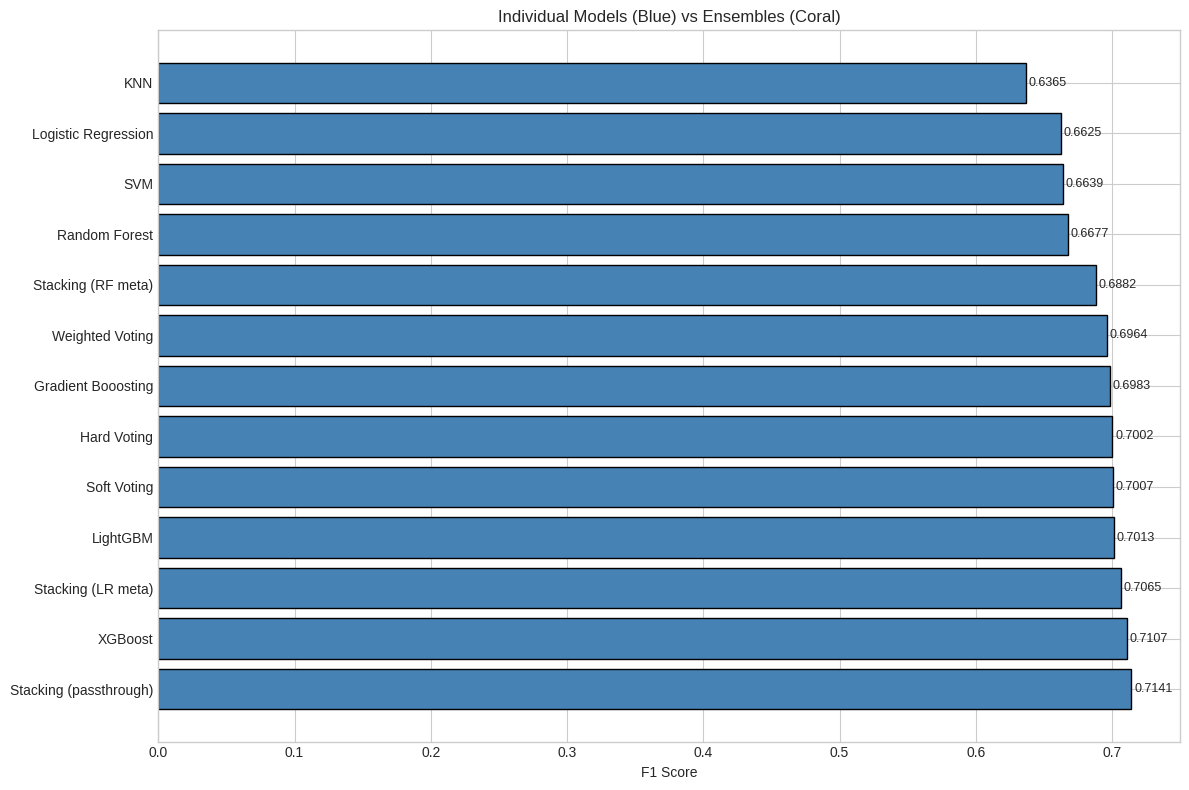

In [30]:
# Visual comparison
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['steelblue' if '🗳️' not in m and '🏗️' not in m else 'coral'
          for m in final_df['Model']]

bars = ax.barh(final_df['Model'], final_df['F1'], color=colors, edgecolor='black')
ax.set_xlabel('F1 Score')
ax.set_title('Individual Models (Blue) vs Ensembles (Coral)')

# Add values
for bar, val in zip(bars, final_df['F1']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Summary

### Ensemble Methods

| Method | How It Works | Best For |
|--------|--------------|----------|
| Hard Voting | Majority class wins | Simple, fast |
| Soft Voting | Average probabilities | Usually better |
| Weighted Voting | Weight by performance | When models differ |
| Stacking | Meta-learner combines | Best performance |

### Key Takeaways

1. **Diversity matters** — combine different model types
2. **Soft > Hard** — use probabilities when available
3. **Stacking** — learns optimal combination
4. **Diminishing returns** — improvement often small
5. **Trade-off** — more complexity, slower inference

### Typical Improvement

- Voting: 0.5-2% over best individual
- Stacking: 1-3% over best individual
- Kaggle winners often stack 10+ models!